# ARTI308 – Machine Learning
## Lab 6 Task: Linear Regression on Ecommerce Customers Dataset

In this task we apply **Linear Regression** (the same model used in the USA Housing lab) to the Ecommerce Customers dataset to predict **Yearly Amount Spent** by customers.

## Step 1 – Import Libraries & Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

# Load the dataset
df = pd.read_csv('Ecommerce_Customers.csv')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')

Dataset loaded successfully!
Shape: (500, 8)


## Step 2 – Explore the Data

In [2]:
# First 5 rows
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
# Column types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
# Summary statistics
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


**Observations:**
- 500 records, 8 columns
- 3 non-numeric columns: `Email`, `Address`, `Avatar` — not useful as features
- 5 numeric columns, all float64
- No missing values → no imputation needed
- Target variable: `Yearly Amount Spent`

## Step 3 – Data Cleaning

In [6]:
# Drop non-numeric, non-informative columns
df_clean = df.drop(columns=['Email', 'Address', 'Avatar'])

print('Cleaned dataset shape:', df_clean.shape)
df_clean.head()

Cleaned dataset shape: (500, 5)


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


## Step 4 – Feature Engineering

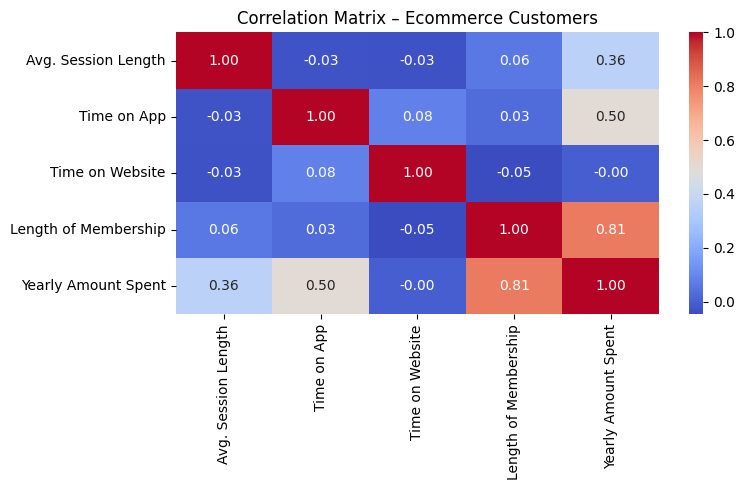

In [7]:
# Correlation matrix to understand feature relationships
plt.figure(figsize=(8, 5))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix – Ecommerce Customers')
plt.tight_layout()
plt.show()

In [8]:
# Correlation with target variable
print('Correlation with Yearly Amount Spent:')
print(df_clean.corr()['Yearly Amount Spent'].sort_values(ascending=False))

Correlation with Yearly Amount Spent:
Yearly Amount Spent     1.000000
Length of Membership    0.809084
Time on App             0.499328
Avg. Session Length     0.355088
Time on Website        -0.002641
Name: Yearly Amount Spent, dtype: float64


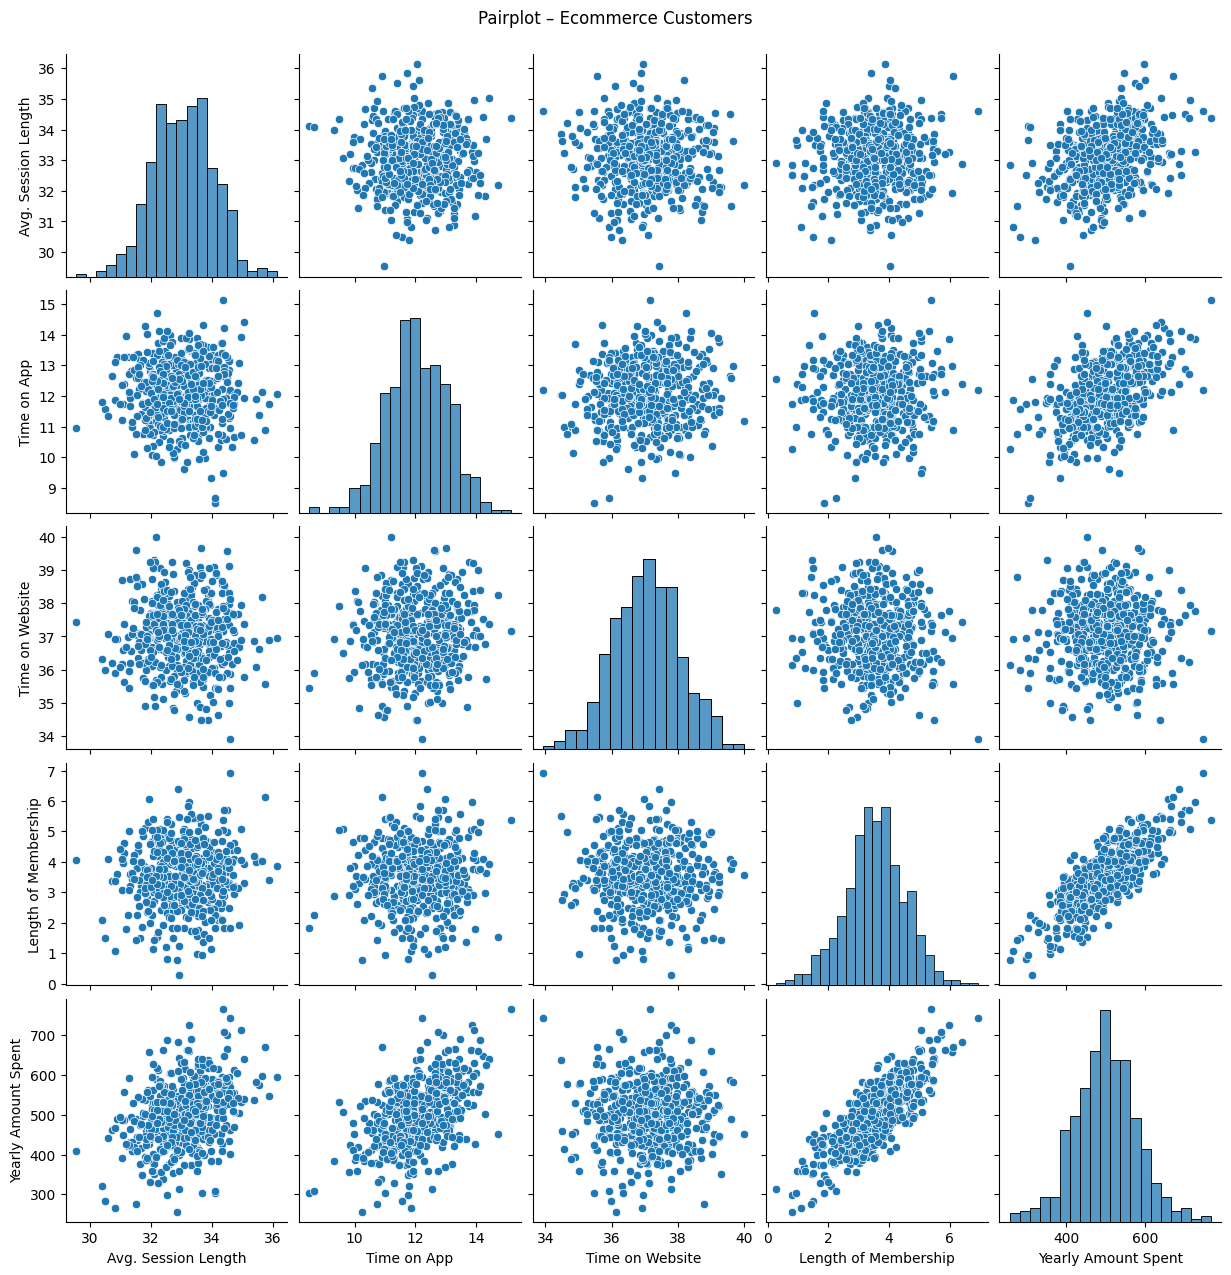

In [9]:
# Pairplot to visualize relationships
sns.pairplot(df_clean)
plt.suptitle('Pairplot – Ecommerce Customers', y=1.02)
plt.show()

**Feature Engineering Insights:**
- `Length of Membership` has the **strongest correlation** with the target (r = 0.81)
- `Time on App` is the second strongest predictor (r = 0.50)
- `Time on Website` has almost no correlation (r ≈ -0.003)
- All 4 numeric features are retained — no new features are needed given the strong linearity already present

## Step 5 – Prepare the Data for Modeling

In [10]:
# Define features (X) and target (y)
X = df_clean.drop('Yearly Amount Spent', axis=1)
y = df_clean['Yearly Amount Spent']

print('Features:', list(X.columns))
print('Target: Yearly Amount Spent')

# Train/Test split — 70% train, 30% test (same split ratio as the lab)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

print(f'\nTraining set size: {X_train.shape}')
print(f'Test set size:     {X_test.shape}')

Features: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']
Target: Yearly Amount Spent

Training set size: (350, 4)
Test set size:     (150, 4)


## Step 6 – Train the Linear Regression Model

In [11]:
# Instantiate and train the model
lm = LinearRegression()
lm.fit(X_train, y_train)

print('Model trained successfully!')

# Display intercept and coefficients
print(f'\nIntercept: {lm.intercept_:.4f}')
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print('\nCoefficients:')
print(coeff_df)

Model trained successfully!

Intercept: -1047.9328

Coefficients:
                      Coefficient
Avg. Session Length     25.981550
Time on App             38.590159
Time on Website          0.190405
Length of Membership    61.279097


**Coefficient Interpretation:**
- **Length of Membership (+61.28):** Each additional year of membership increases yearly spending by ~$61.28 — the most influential feature
- **Time on App (+38.59):** Each extra minute on the app adds ~$38.59 to yearly spending
- **Avg. Session Length (+25.98):** Longer sessions correlate with higher spending
- **Time on Website (+0.19):** Negligible effect on spending

## Step 7 – Evaluate Model Performance

In [12]:
# Make predictions on the test set
predictions = lm.predict(X_test)

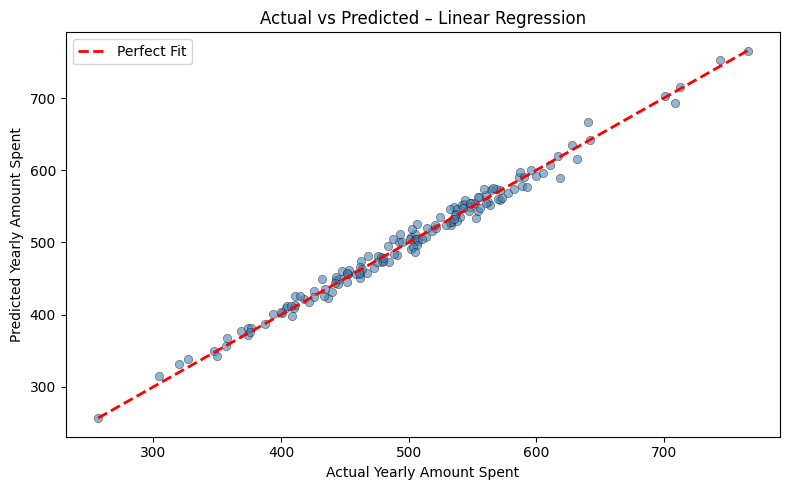

In [13]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted – Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

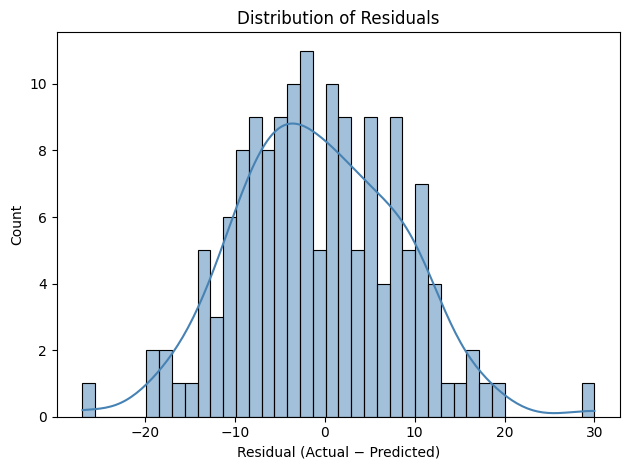

In [14]:
# Residuals distribution
residuals = y_test - predictions
sns.histplot(residuals, bins=40, kde=True, color='steelblue')
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()

In [15]:
# Evaluation Metrics
mae  = metrics.mean_absolute_error(y_test, predictions)
mse  = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2   = metrics.r2_score(y_test, predictions)

print('=== Regression Evaluation Metrics ===')
print(f'MAE  (Mean Absolute Error):       ${mae:.2f}')
print(f'MSE  (Mean Squared Error):        ${mse:.2f}')
print(f'RMSE (Root Mean Squared Error):   ${rmse:.2f}')
print(f'R²   (Coefficient of Determination): {r2:.4f}')

=== Regression Evaluation Metrics ===
MAE  (Mean Absolute Error):       $7.23
MSE  (Mean Squared Error):        $79.81
RMSE (Root Mean Squared Error):   $8.93
R²   (Coefficient of Determination): 0.9890


## Summary

| Metric | Value |
|--------|-------|
| MAE    | $7.23 |
| MSE    | $79.81 |
| RMSE   | $8.93 |
| R²     | 0.989 |

The Linear Regression model performs **exceptionally well** on the Ecommerce Customers dataset:
- An **R² of 0.989** means the model explains ~98.9% of the variance in yearly spending
- The **RMSE of \$8.93** is very small relative to the average spend of ~\$499, indicating highly accurate predictions
- The residuals histogram shows a roughly **normal distribution centered near zero**, confirming that the linear regression assumptions are well-satisfied
- **Length of Membership** and **Time on App** are the most important predictors of customer spending